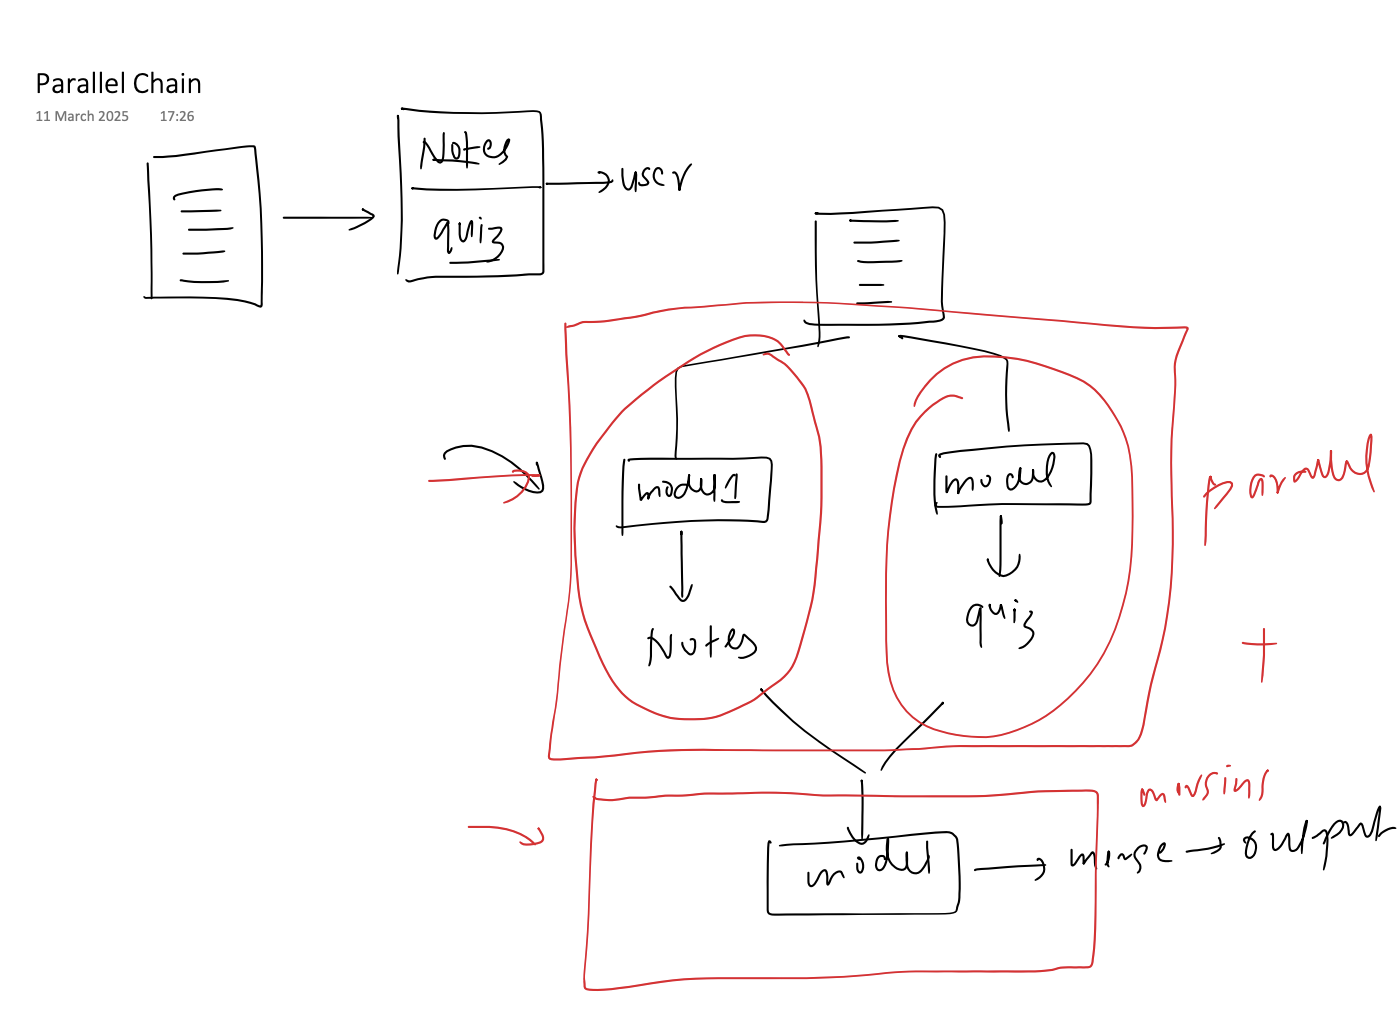

This example shows how to execute two different tasks concurrently on the same
input. We will take a detailed text (e.g., about Linear Regression) and generate
both study notes and a quiz from it in parallel. Finally, we merge both outputs
into a single document.
• Explanation:
1. Prompts:
▪ note_prompt : Instructs a model to generate
short, simple notes.
▪ quiz_prompt : Instructs a model to generate
five short question-answers.
74
▪ merge_prompt : Instructs a model to merge the
provided notes and quiz into a single document.
2. Parallel Chain Creation ( RunnableParallel ): This is the
key component. It allows us to run two different chains
simultaneously.
▪ notes_chain : note_prompt | model1 |
parser
▪ quiz_chain : quiz_prompt | model2 |
parser (Note: we can use different models,
e.g., OpenAI for one and Anthropic for the
other).
▪ These are passed to RunnableParallel to
create a parallel branch.
3. Merging Chain: The output from the parallel branch (a
dictionary with keys 'notes' and 'quiz') is fed into the
merge_prompt , then through a final model and parser.
4. Final Chain: The complete pipeline is parallel_chain |
merge_chain .

In [7]:
text="""
Support vector machines (SVMs) are a set of supervised learning methods used for classification, regression and outliers detection.

The advantages of support vector machines are:

Effective in high dimensional spaces.

Still effective in cases where number of dimensions is greater than the number of samples.

Uses a subset of training points in the decision function (called support vectors), so it is also memory efficient.

Versatile: different Kernel functions can be specified for the decision function. Common kernels are provided, but it is also possible to specify custom kernels.

The disadvantages of support vector machines include:

If the number of features is much greater than the number of samples, avoid over-fitting in choosing Kernel functions and regularization term is crucial.

SVMs do not directly provide probability estimates, these are calculated using an expensive five-fold cross-validation (see Scores and probabilities, below).

The support vector machines in scikit-learn support both dense (numpy.ndarray and convertible to that by numpy.asarray) and sparse (any scipy.sparse) sample vectors as input. However, to use an SVM to make predictions for sparse data, it must have been fit on such data. For optimal performance, use C-ordered numpy.ndarray (dense) or scipy.sparse.csr_matrix (sparse) with dtype=float64.
"""

### 1.define models and parsers

In [1]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
import os

# Load environment variables
load_dotenv()

api_key = os.getenv("Hugging_face_api_token")

# Create LLM endpoint
llm = HuggingFaceEndpoint(
    # repo_id="TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    repo_id="mistralai/Mistral-7B-Instruct-v0.2",
    task="text-generation",
    huggingfacehub_api_token=api_key,
)

# Wrap with chat interface
# two models required as seen from figure
model1 = ChatHuggingFace(llm=llm)
model2=ChatHuggingFace(llm=llm)

In [2]:
from langchain_core.output_parsers import StrOutputParser
parser=StrOutputParser()

### 2.define the prompt templates

In [4]:
from langchain_core.prompts import PromptTemplate

# first prompt for generating detail from the given text
note_prompt=PromptTemplate(
    template="Generate the short and simple notes from the following text \n {text}",
    input_variables=["text"]
)

#second prompt to generate quiz from the same given text parallely
quiz_prompt=PromptTemplate(
    template="Generate 5 short question answers from the following text \n {text}",
    input_variables=["text"]
)

#third prompt for merging both
merge_prompt=PromptTemplate(
    template="Merge the provided notes and quiz into a single document \n notes -> {notes} and quiz->{quiz}",
    input_variables=["notes","quiz"]
)

### 3.define the chain and invoke

In [8]:
from langchain_core.runnables import RunnableParallel

#1.Create parallel chain
parallel_chain=RunnableParallel(
    {
        "notes":note_prompt|model1|parser,#"notes"->required input for merged chain prompt template that is 2nd step
        "quiz":quiz_prompt|model2|parser,#"quiz"->required input for merged chain prompt template that is 2nd step
    }
)

#2.create Merge chain.
merge_chain=merge_prompt|model1|parser

#3.create the final chain ,joining these chains as structured
final_chain=parallel_chain|merge_chain

#invoking the chain

result=final_chain.invoke({
    "text":text # first input which is required to parallel chains
})

### 5.Output

In [9]:
print(result)
print(type(result))

 Support Vector Machines (SVMs) are a supervised learning method capable of addressing various tasks in machine learning, including classification, regression, and outliers detection. SVMs are effective in high-dimensional spaces due to their ability to handle the curse of dimensionality and efficiently identify patterns in large datasets. The algorithm's effectiveness relies on a subset of training points called support vectors.

Support vectors are essential to SVMs since they are used in the decision function, allowing the algorithm to make accurate predictions. SVMs support various kernel functions to create the decision function, making them versatile and applicable to a wide range of data types.

However, SVMs have certain disadvantages. One major issue is the risk of over-fitting when the number of features significantly exceeds the number of samples. Careful selection of the kernel function and regularization term is essential to mitigate this problem. Additionally, SVMs do not

### 5.Output Graph

In [10]:
final_chain.get_graph().print_ascii()

              +---------------------------+              
              | Parallel<notes,quiz>Input |              
              +---------------------------+              
                  ***               ***                  
               ***                     ***               
             **                           **             
+----------------+                    +----------------+ 
| PromptTemplate |                    | PromptTemplate | 
+----------------+                    +----------------+ 
          *                                   *          
          *                                   *          
          *                                   *          
+-----------------+                  +-----------------+ 
| ChatHuggingFace |                  | ChatHuggingFace | 
+-----------------+                  +-----------------+ 
          *                                   *          
          *                                   *          
          *   